**Kirjastojen tuonti ja asetukset**

Mitä tässä tehdään:

 Tuodaan kaikki tarvittavat Python-kirjastot ja lukitaan satunnaislukugeneraattoreiden siemenluvut (seeds). Valitaan myös automaattisesti laskentaan käytettävä laite (CPU tai GPU).Miksi tämä tehdään: Koneoppimiskokeiluissa tulosten toistettavuus on äärimmäisen tärkeää. Kun asetamme siemenluvut kiinteiksi (esim. SEED = 42), varmistamme, että mallin painoarvojen alustus ja datan sekoitus tapahtuvat aina samalla tavalla, jolloin koodin uudelleen ajaminen tuottaa samat tulokset. Laitteen valinta varmistaa koodin siirrettävyyden eri koneiden välillä.   

In [2]:
# --- Standard libraries ---
import os, time, random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# --- Scikit-learn for metrics ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# --- Reproducibility (Opettajan esimerkin mukaisesti) ---
SEED = 42
random.seed(SEED)                  
np.random.seed(SEED)               
torch.manual_seed(SEED)            
torch.cuda.manual_seed_all(SEED)   

# --- Device selection ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Käytössä oleva laite: {device}")

Käytössä oleva laite: cpu


**Datan esikäsittely ja lataus**

Mitä tässä tehdään:
Määritellään kuvien muunnokset (koko, tensoriksi muuttaminen ja normalisointi). Ladataan kuvat opetus-, validointi- ja testikansioista (ImageFolder) ja luodaan niistä iteroidut eräkokokäsittelijät (DataLoader).

Miksi tämä tehdään: Esiopetetut mallit, kuten ResNet, on koulutettu ImageNet-datalla, ja ne vaativat, että syötekuvat skaalataan kokoon 224x224 ja normalisoidaan samoilla keskiarvoilla ja hajonnoilla kuin alkuperäinen opetusdata. Opetusdataan on lisätty pientä satunnaisuutta (Data Augmentation: kääntö ja rajaus), mikä auttaa mallia yleistämään oppimaansa paremmin. DataLoadereiden avulla data syötetään mallille pienissä erissä (batches) ja opetusdata sekoitetaan (shuffle), mikä on tärkeää stokastisen gradienttilaskun (SGD/Adam) toiminnalle.

In [3]:
data_dir = 'tree' 

# 1. Määritellään muunnokset (Transforms)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Ladataan datasetit
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

# 3. Luodaan DataLoaders
batch_size = 32
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"Löydettiin {num_classes} luokkaa.")
print(f"Kuvia - Train: {len(image_datasets['train'])}, Val: {len(image_datasets['val'])}, Test: {len(image_datasets['test'])}")

Löydettiin 23 luokkaa.
Kuvia - Train: 3850, Val: 482, Test: 472


**Yleiskäyttöinen harjoitus- ja arviointifunktio (run_epoch)**

Mitä tässä tehdään:
Funktio käy koko annetun datasatsin läpi kerran (yksi epookki). Jos is_train=True, se päivittää mallin painoarvoja backpropagation-algoritmilla; muuten se toimii vain arviointitilassa.

Miksi tämä tehdään: Tämä pitää varsinaisen harjoitussilmukan siistinä ja kompaktina. Mallin asettaminen oikeaan tilaan (model.train() tai model.eval()) on kriittistä, sillä se vaikuttaa esimerkiksi Dropout- ja BatchNorm-kerrosten toimintaan. Funktio laskee ja palauttaa lopuksi moniluokitteluun soveltuvat arviointimittarit (esim. F1-score 'weighted'-asetuksella).

In [4]:
def run_epoch(model, dataloader, criterion, optimizer=None, is_train=True):
    """
    Yksi kokonainen läpikäynti dataloadrille (epookki).
    Opettajan Lab_05 run_epoch -funktion pohjalta muokattu moniluokitteluun.
    """
    # Asetetaan malli oikeaan tilaan (opetus vs. arviointi)
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in dataloader:
        # Siirretään data samalle laitteelle kuin malli
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Nollataan gradientit opetusvaiheessa
        if is_train and optimizer is not None:
            optimizer.zero_grad()

        # Eteenpäin syöttö (Forward pass) ja häviön laskenta.
        # Lasketaan gradientit vain opetusvaiheessa.
        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Etsitään korkeimman todennäköisyyden saanut luokka (0-22)
            _, preds = torch.max(outputs, 1)

            # Taaksepäin levitys ja painojen päivitys opetusvaiheessa
            if is_train and optimizer is not None:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Koko epookin keskiarvotiedot
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    
    pr, rc, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    return epoch_loss, acc, pr, rc, f1, all_labels, all_preds

**Mallin alustus ja pääharjoitussilmukka**

Mitä tässä tehdään: 
Alustetaan ResNet18-malli siirto-oppimista varten korvaamalla sen alkuperäinen tulostekerros meidän 23 luokan kerroksella. Tämän jälkeen ajetaan toistuva silmukka, joka vuorotellen opettaa ja validoi mallia, ja tallentaa tulokset sanakirjaan (history).

Miksi tämä tehdään: Siirto-oppiminen on tehokas tapa hyödyntää muihin tehtäviin kehitettyjä monimutkaisia ominaisuuksien erottelijoita, mikä nopeuttaa ja parantaa oppimista. Harjoitussilmukka noudattaa opettajan esimerkin mukaista selkeää mallia, jossa koulutus- ja validointivaiheet on selkeästi erotettu ja tulokset tallennetaan vertailua varten.

In [5]:
# Ladataan esiopetettu ResNet18-malli
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Korvataan viimeinen kerros (fc) 23 puuluokkaan sopivaksi
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)
model_resnet18 = model_resnet18.to(device)

# Moniluokitteluun käytetään CrossEntropyLoss -funktiota
criterion = nn.CrossEntropyLoss()

# Optimoijaksi Adam
optimizer = optim.Adam(model_resnet18.parameters(), lr=0.001)

num_epochs = 5 
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Aloitetaan mallin opetus...")

for epoch in range(num_epochs):
    print(f"Epookki {epoch+1}/{num_epochs}")
    print("-" * 10)

    # 1. Opetusvaihe (päivittää painoarvoja)
    train_loss, train_acc, _, _, _, _, _ = run_epoch(
        model_resnet18, dataloaders['train'], criterion, optimizer, is_train=True
    )
    
    # 2. Validointivaihe (arvioi suorituskykyä näkemättömällä datalla)
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(
        model_resnet18, dataloaders['val'], criterion, is_train=False
    )

    # Tallennetaan historia kuvaajia varten (Opettajan esimerkin mukaisesti)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

print("Opetus valmis!")

Aloitetaan mallin opetus...
Epookki 1/5
----------
Train Loss: 2.2202 | Train Acc: 0.3418
Val Loss:   5.0661 | Val Acc:   0.1743 | Val F1: 0.1543

Epookki 2/5
----------
Train Loss: 1.6410 | Train Acc: 0.5070
Val Loss:   3.3347 | Val Acc:   0.3797 | Val F1: 0.3425

Epookki 3/5
----------
Train Loss: 1.3431 | Train Acc: 0.5914
Val Loss:   1.5947 | Val Acc:   0.5768 | Val F1: 0.5383

Epookki 4/5
----------
Train Loss: 1.1364 | Train Acc: 0.6499
Val Loss:   2.0754 | Val Acc:   0.4502 | Val F1: 0.4096

Epookki 5/5
----------
Train Loss: 1.0356 | Train Acc: 0.6857
Val Loss:   1.8893 | Val Acc:   0.5270 | Val F1: 0.5035

Opetus valmis!


In [6]:
# Asetetaan 25 epookkia, jotta malli ehtii oppia kunnolla
import time


num_epochs = 25 
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Aloitetaan mallin opetus (25 epookkia)...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epookki {epoch+1}/{num_epochs}")
    
    # 1. Opetusvaihe
    train_loss, train_acc, _, _, _, _, _ = run_epoch(
        model_resnet18, dataloaders['train'], criterion, optimizer, is_train=True
    )
    
    # 2. Validointivaihe
    val_loss, val_acc, val_pr, val_rc, val_f1, _, _ = run_epoch(
        model_resnet18, dataloaders['val'], criterion, is_train=False
    )

    # Tallennetaan tulokset
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

total_time = time.time() - start_time
print(f"Opetus valmis! Aikaa kului: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Aloitetaan mallin opetus (25 epookkia)...
Epookki 1/25
Train Loss: 0.9888 | Train Acc: 0.7008
Val Loss:   2.7841 | Val Acc:   0.4149 | Val F1: 0.3763

Epookki 2/25
Train Loss: 0.8929 | Train Acc: 0.7296
Val Loss:   1.7109 | Val Acc:   0.5892 | Val F1: 0.5624

Epookki 3/25
Train Loss: 0.7960 | Train Acc: 0.7512
Val Loss:   1.1527 | Val Acc:   0.6888 | Val F1: 0.6706

Epookki 4/25
Train Loss: 0.7588 | Train Acc: 0.7655
Val Loss:   1.4225 | Val Acc:   0.6494 | Val F1: 0.6208

Epookki 5/25
Train Loss: 0.7057 | Train Acc: 0.7865
Val Loss:   0.6244 | Val Acc:   0.8299 | Val F1: 0.8338

Epookki 6/25
Train Loss: 0.7062 | Train Acc: 0.7878
Val Loss:   0.6937 | Val Acc:   0.8029 | Val F1: 0.7990

Epookki 7/25
Train Loss: 0.6901 | Train Acc: 0.7894
Val Loss:   0.7475 | Val Acc:   0.7676 | Val F1: 0.7634

Epookki 8/25
Train Loss: 0.6334 | Train Acc: 0.8057
Val Loss:   3.2843 | Val Acc:   0.4896 | Val F1: 0.4646

Epookki 9/25
Train Loss: 0.6257 | Train Acc: 0.8075
Val Loss:   0.9391 | Val Acc:   0.

**Oppimiskäyrien visualisointi**

Mitä tässä tehdään: 
Piirretään matplotlib-kirjastolla kaksi kuvaajaa. Toinen näyttää häviön (loss) ja toinen tarkkuuden (accuracy) kehityksen opetus- ja validointidatalla.
Miksi tämä tehdään: Visuaaliset käyrät ovat paras tapa havaita, oppiiko malli oikein vai alkaako se ylisovittua (overfit). Jos validointihäviö alkaa nousta, vaikka opetushäviö jatkaa laskuaan, malli ylisovittuu.

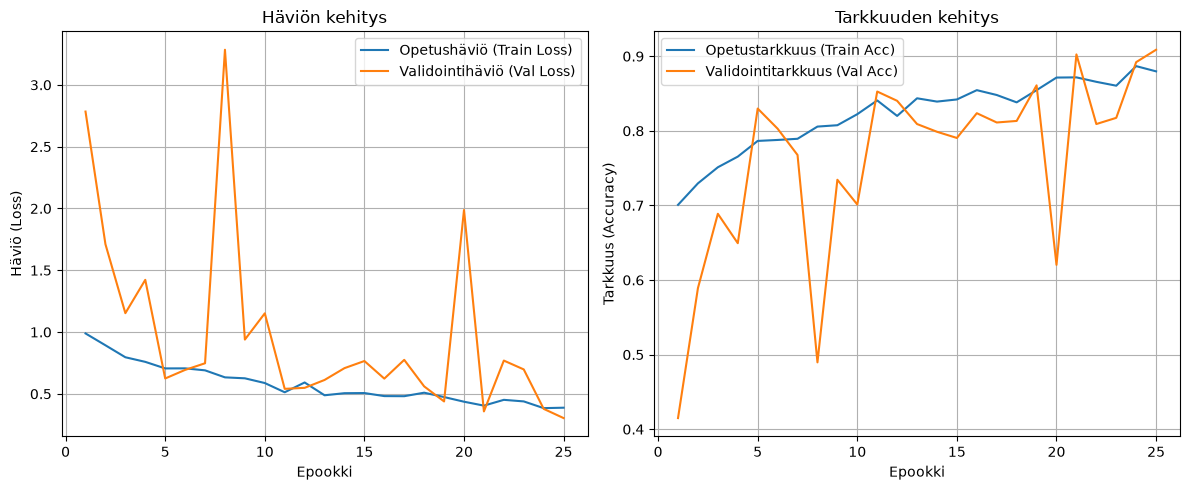

In [7]:
# Piirretään häviö- ja tarkkuuskäyrät
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Häviö (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Opetushäviö (Train Loss)')
plt.plot(epochs_range, history['val_loss'], label='Validointihäviö (Val Loss)')
plt.title('Häviön kehitys')
plt.xlabel('Epookki')
plt.ylabel('Häviö (Loss)')
plt.legend()
plt.grid(True)

# Tarkkuus (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Opetustarkkuus (Train Acc)')
plt.plot(epochs_range, history['val_acc'], label='Validointitarkkuus (Val Acc)')
plt.title('Tarkkuuden kehitys')
plt.xlabel('Epookki')
plt.ylabel('Tarkkuus (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Lopullinen testaus, sekaannusmatriisi ja n-best -tarkkuus**

Mitä tässä tehdään:
 Projektiohjeen mukaisesti arvioimme mallin suorituskykyä täysin ennennäkemättömällä testidatalla (test_loader). Laskemme tarkkuuden, F1-pisteet, piirrämme sekaannusmatriisin (Confusion Matrix) ja teemme n-best -arvioinnin (esim. top-1, top-3, top-5).
Miksi tämä tehdään:
 Testidata kertoo mallin todellisen suorituskyvyn tuotannossa. Sekaannusmatriisi on kriittinen, jotta voitte raportissanne analysoida, "tekeekö malli virheitä, jotka toistavat itseään" (kuten tehtävänanto vaatii). Top-N -mittarit paljastavat, oliko oikea puulaji mallin mielestä lähellä (vaikka paras arvaus olisikin ollut väärin).

Arvioidaan mallia Testi-datalla...
Testitulokset: Tarkkuus (Acc): 0.8602 | Täsmällisyys (Precision): 0.8736 | Saanti (Recall): 0.8602 | F1: 0.8581


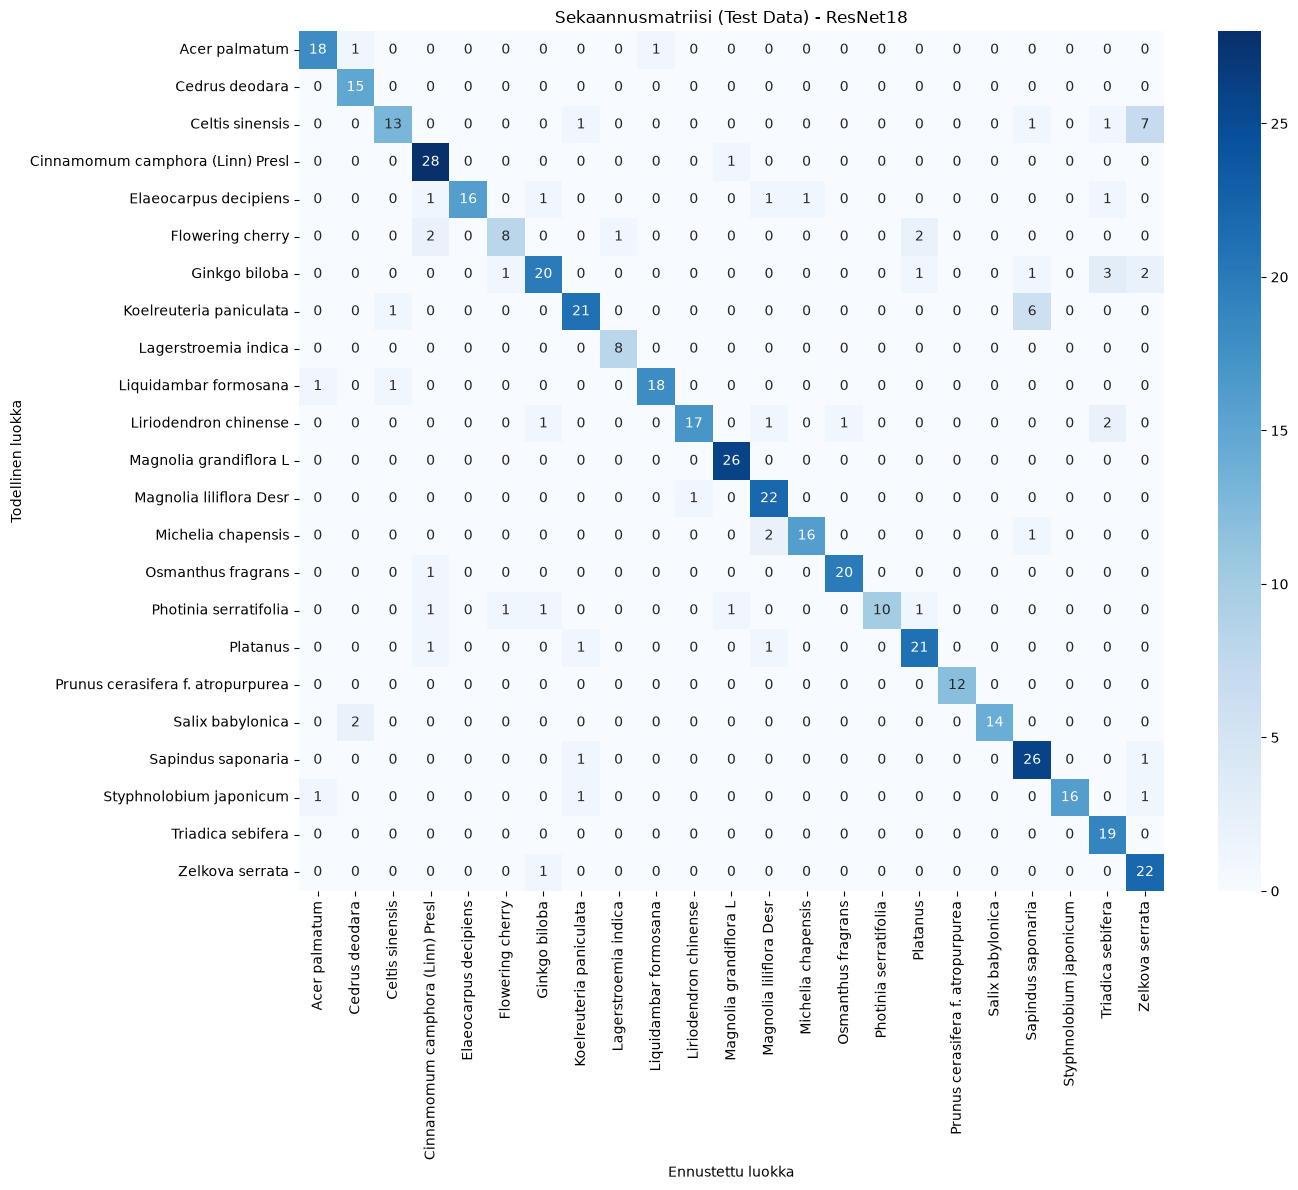


N-best luokittelutulokset (Test Data):
Top-1 Tarkkuus: 0.8602
Top-2 Tarkkuus: 0.9301
Top-3 Tarkkuus: 0.9555
Top-5 Tarkkuus: 0.9788


In [8]:
print("Arvioidaan mallia Testi-datalla...")
# 1. Perusmittarit testidatalle
test_loss, test_acc, test_pr, test_rc, test_f1, test_labels, test_preds = run_epoch(
    model_resnet18, dataloaders['test'], criterion, is_train=False
)

print(f"Testitulokset: Tarkkuus (Acc): {test_acc:.4f} | Täsmällisyys (Precision): {test_pr:.4f} | Saanti (Recall): {test_rc:.4f} | F1: {test_f1:.4f}")

# 2. Sekaannusmatriisi (Confusion Matrix)
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Sekaannusmatriisi (Test Data) - ResNet18')
plt.xlabel('Ennustettu luokka')
plt.ylabel('Todellinen luokka')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Top-N tarkkuuden laskenta (Tehtävänannon "n-best" vaatimus)
def evaluate_top_n(model, dataloader, top_n_list=[1, 3, 5]):
    model.eval()
    correct_counts = {n: 0 for n in top_n_list}
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            total += labels.size(0)
            
            # Etsitään n suurinta todennäköisyyttä
            max_n = max(top_n_list)
            _, top_preds = outputs.topk(max_n, dim=1, largest=True, sorted=True)
            
            for n in top_n_list:
                # Katsotaan onko oikea vastaus top-N joukossa
                correct = top_preds[:, :n].eq(labels.view(-1, 1).expand_as(top_preds[:, :n]))
                correct_counts[n] += correct.sum().item()
                
    for n in top_n_list:
        acc = correct_counts[n] / total
        print(f"Top-{n} Tarkkuus: {acc:.4f}")

print("\nN-best luokittelutulokset (Test Data):")
evaluate_top_n(model_resnet18, dataloaders['test'], top_n_list=[1, 2, 3, 5])